## Standardization

### Less sensitive to Outliers

In [4]:
import pandas as pd
df=pd.read_csv('titanic.csv', usecols=['Pclass','Age','Fare','Survived'])
df.head()

,Survived,Pclass,Age,Fare
0,0,3,22.0,7.2500
1,1,1,38.0,71.2833
2,1,3,26.0,7.9250
3,1,1,35.0,53.1000
4,0,3,35.0,8.0500


In [5]:
df.isnull().sum()

Survived      0
Pclass        0
Age         177
Fare          0
dtype: int64

In [6]:
df['Age'].fillna(df.Age.median(),inplace=True)

C:\Users\KRISHNA\AppData\Local\Temp\ipykernel_20016\2569459057.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df.Age.median(),inplace=True)


In [7]:
df.isnull().sum()

Survived    0
Pclass      0
Age         0
Fare        0
dtype: int64

In [8]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

In [9]:
X

,Pclass,Age,Fare
0,3,22.0,7.2500
1,1,38.0,71.2833
2,3,26.0,7.9250
3,1,35.0,53.1000
4,3,35.0,8.0500
...,...,...,...
886,2,27.0,13.0000
887,1,19.0,30.0000
888,3,28.0,23.4500
889,1,26.0,30.0000


In [10]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [12]:
X_train

,Pclass,Age,Fare
6,1,54.0,51.8625
718,3,28.0,15.5000
685,2,25.0,41.5792
73,3,26.0,14.4542
882,3,22.0,10.5167
...,...,...,...
106,3,21.0,7.6500
270,1,28.0,31.0000
860,3,41.0,14.1083
435,1,14.0,120.0000


In [13]:
#### standarisation: We use the Standardscaler from sklearn library
from sklearn.preprocessing import StandardScaler

In [14]:
scaler=StandardScaler()
### fit vs fit_transform
X_train_scaled=scaler.fit_transform(X_train)
X_train_scaled

array([[-1.62580285,  1.91349292,  0.38784185],
       [ 0.80576177, -0.09452019, -0.31908053],
       [-0.41002054, -0.32621401,  0.18792449],
       ...,
       [ 0.80576177,  0.90948636, -0.34613654],
       [-1.62580285, -1.17575802,  1.71250117],
       [-1.62580285, -0.63513911,  0.8821286 ]], shape=(596, 3))

In [15]:
X_test_scaled=scaler.transform(X_test)
X_test_scaled

array([[ 0.80576177, -0.09452019, -0.32402243],
       [-0.41002054,  0.13717363, -0.4162854 ],
       [ 0.80576177, -0.71237038, -0.46634591],
       [-0.41002054, -1.79360821,  0.0211365 ],
       [ 0.80576177, -1.17575802, -0.40186603],
       [-1.62580285, -0.24898274,  0.91250512],
       [ 0.80576177, -0.09452019, -0.46974808],
       [ 0.80576177, -1.02129548, -0.2704781 ],
       [ 0.80576177, -1.02129548, -0.46974808],
       [-1.62580285, -0.78960166, -0.10944269],
       [-1.62580285,  0.60056127,  0.41190006],
       [ 0.80576177,  1.14118018, -0.46391578],
       [ 0.80576177, -0.09452019, -0.12531819],
       [ 0.80576177,  0.05994235, -0.47995459],
       [-0.41002054,  0.52332999, -0.36768297],
       [-1.62580285, -1.02129548,  0.14555873],
       [-1.62580285,  0.98671764,  0.40128918],
       [ 0.80576177, -0.09452019, -0.46820835],
       [-0.41002054, -0.17175147, -0.36768297],
       [-1.62580285,  1.372874  ,  0.39051499],
       [ 0.80576177, -0.40344529, -0.466

In [16]:
from sklearn.linear_model import LogisticRegression
classification=LogisticRegression()
classification.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
classification.predict(X_test_scaled)

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0])

In [18]:
df_scaled = scaler.transform(X)

In [19]:
df_scaled

array([[ 0.80576177, -0.55790784, -0.47946856],
       [-1.62580285,  0.67779254,  0.76540111],
       [ 0.80576177, -0.24898274, -0.46634591],
       ...,
       [ 0.80576177, -0.09452019, -0.1645248 ],
       [-1.62580285, -0.24898274, -0.03718642],
       [ 0.80576177,  0.2144049 , -0.46974808]], shape=(891, 3))

In [20]:
import matplotlib.pyplot as plt
%matplotlib inline

(array([ 40.,  14.,  15.,  31.,  79.,  98., 262.,  84.,  73.,  45.,  35.,
         35.,  29.,  16.,  13.,  11.,   4.,   5.,   1.,   1.]),
 array([-2.22455872, -1.91725548, -1.60995224, -1.30264901, -0.99534577,
        -0.68804253, -0.38073929, -0.07343606,  0.23386718,  0.54117042,
         0.84847366,  1.15577689,  1.46308013,  1.77038337,  2.07768661,
         2.38498985,  2.69229308,  2.99959632,  3.30689956,  3.6142028 ,
         3.92150603]),
 <BarContainer object of 20 artists>)

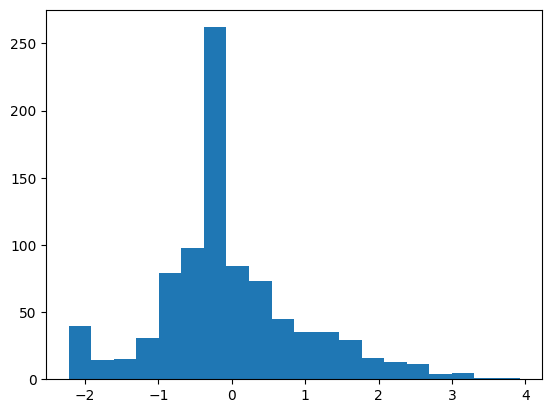

In [21]:
plt.hist(df_scaled[:,1],bins=20) #histogram of the second column (age)

(array([562., 170.,  67.,  39.,  15.,  16.,   2.,   0.,   9.,   2.,   6.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.]),
 array([-0.62041562, -0.12240671,  0.37560221,  0.87361112,  1.37162003,
         1.86962894,  2.36763786,  2.86564677,  3.36365568,  3.8616646 ,
         4.35967351,  4.85768242,  5.35569133,  5.85370025,  6.35170916,
         6.84971807,  7.34772699,  7.8457359 ,  8.34374481,  8.84175372,
         9.33976264]),
 <BarContainer object of 20 artists>)

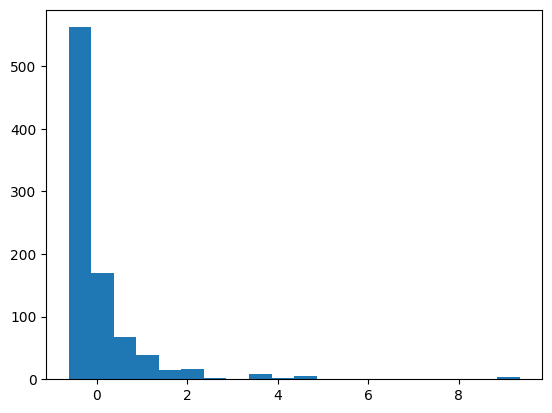

In [22]:
plt.hist(df_scaled[:,2],bins=20)

(array([562., 170.,  67.,  39.,  15.,  16.,   2.,   0.,   9.,   2.,   6.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.]),
 array([  0.     ,  25.61646,  51.23292,  76.84938, 102.46584, 128.0823 ,
        153.69876, 179.31522, 204.93168, 230.54814, 256.1646 , 281.78106,
        307.39752, 333.01398, 358.63044, 384.2469 , 409.86336, 435.47982,
        461.09628, 486.71274, 512.3292 ]),
 <BarContainer object of 20 artists>)

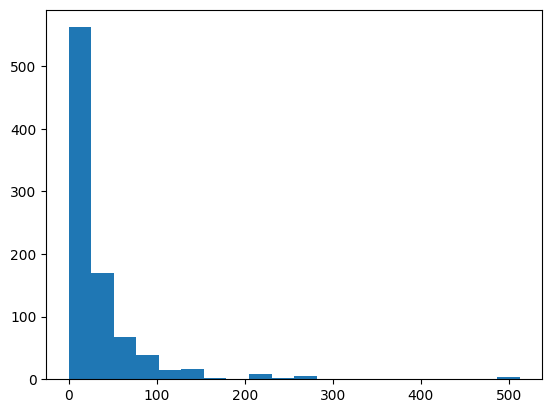

In [23]:
plt.hist(df['Fare'],bins=20)

## Min-Max scaling (Normalization)

### Deep learning Technique
### Min Max Scaling scales the values between 0 to 1.
X_scaled = (X - X_min / (X_max - X_min)

Very sensitive to outliers: very high value in the column of that dataset effects the entire spread in the column because it reaches till value: 1.0 after normalization

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [25]:
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
min_max=MinMaxScaler()
df_minmax = pd.DataFrame(min_max.fit_transform(X_train), columns=X_train.columns)
df_minmax.head()

,Pclass,Age,Fare
0,0.0,0.673285,0.101229
1,1.0,0.346569,0.030254
2,0.5,0.308872,0.081157
3,1.0,0.321438,0.028213
4,1.0,0.271174,0.020527


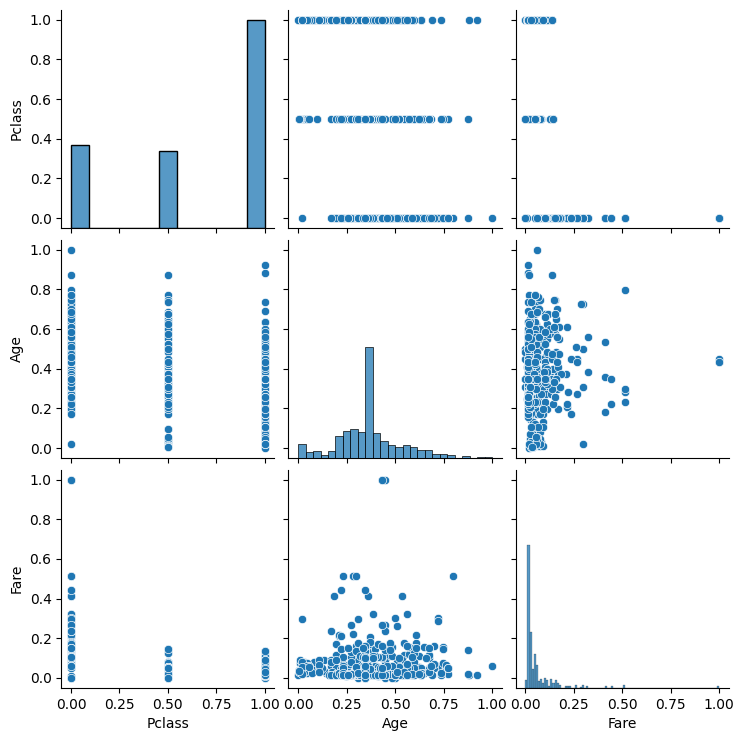

In [26]:
sns.pairplot(df_minmax)

(array([135.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 125.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 336.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

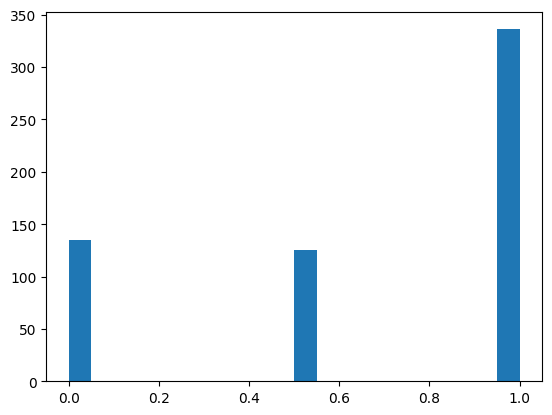

In [27]:
plt.hist(df_minmax['Pclass'],bins=20)

(array([ 29.,   9.,   9.,  23.,  50.,  63., 180.,  56.,  50.,  25.,  24.,
         27.,  16.,  15.,  10.,   5.,   0.,   3.,   1.,   1.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

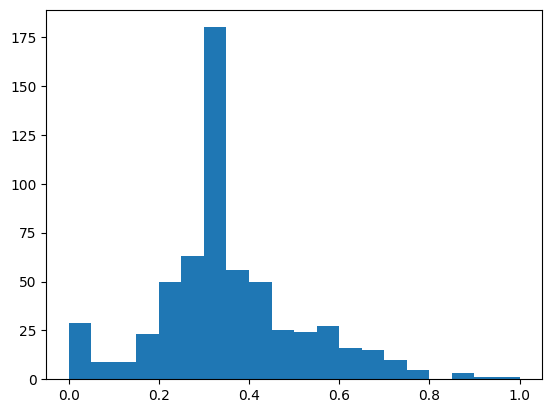

In [28]:
plt.hist(df_minmax['Age'],bins=20)

(array([384., 106.,  51.,  24.,   8.,   9.,   2.,   0.,   5.,   0.,   4.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

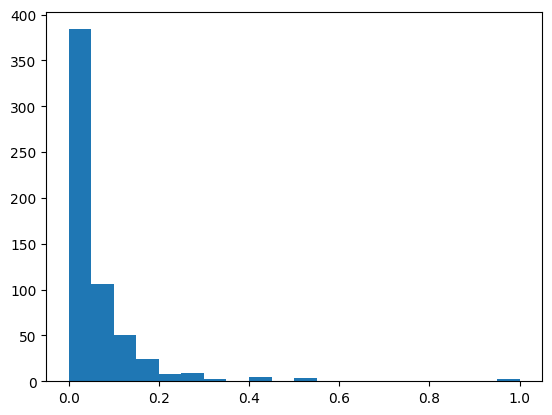

In [29]:
plt.hist(df_minmax['Fare'],bins=20)

### Robust Scaling (Scaling to Median & Quantiles)

Robust Scaling solves that by ignoring outliers completely — instead of using mean/min/max, it uses the median and IQR (Interquartile Range).

# 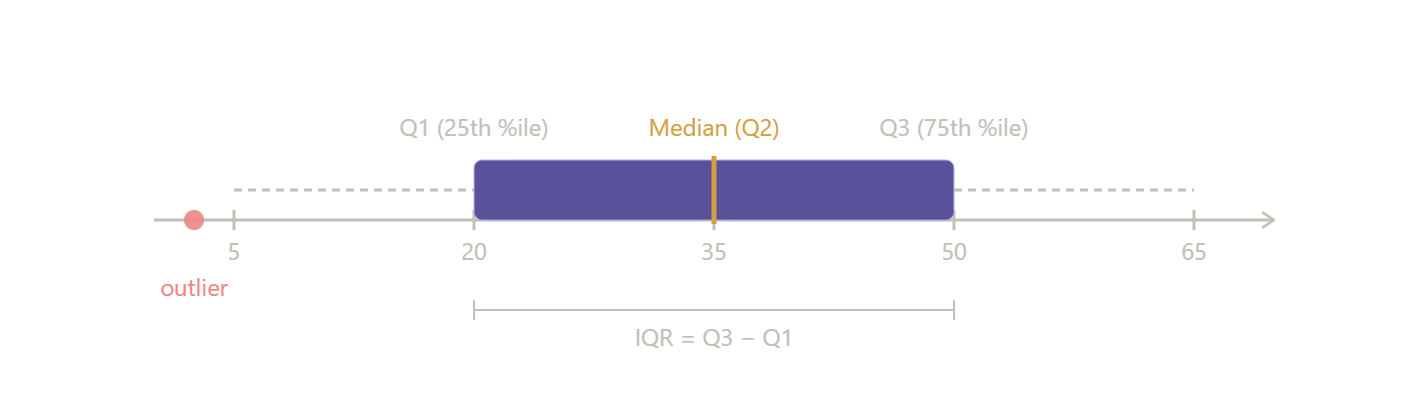

The IQR (Interquartile Range) is simply the middle 50% of your data — from the 25th percentile (Q1) to the 75th percentile (Q3). Outliers that sit far outside this range don't affect it at all.

x_scaled = (x - median) / IQR

Compare that to Standardization which uses mean and std. Here we use median and IQR instead — both of which are completely unaffected by extreme values.

Example:0,1,2,3,4,5,6,7,8,9,10

9-90 percentile---90% of all values in this group is less than 9
1-10 precentile---10% of all values in this group is less than 1
4-40%

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [31]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
df_robust_scaler=pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
df_robust_scaler.head()

,Pclass,Age,Fare
0,-2.0,2.000000,1.602069
1,0.0,0.000000,0.044788
2,-1.0,-0.230769,1.161670
3,0.0,-0.153846,0.000000
4,0.0,-0.461538,-0.168630


In [32]:
scaler.transform(X_test)

array([[ 0.00000000e+00,  0.00000000e+00,  3.39014989e-02],
       [-1.00000000e+00,  2.30769231e-01, -1.69344754e-01],
       [ 0.00000000e+00, -6.15384615e-01, -2.79623126e-01],
       [-1.00000000e+00, -1.69230769e+00,  7.94252677e-01],
       [ 0.00000000e+00, -1.07692308e+00, -1.37580300e-01],
       [-2.00000000e+00, -1.53846154e-01,  2.75785011e+00],
       [ 0.00000000e+00,  0.00000000e+00, -2.87117773e-01],
       [ 0.00000000e+00, -9.23076923e-01,  1.51854390e-01],
       [ 0.00000000e+00, -9.23076923e-01, -2.87117773e-01],
       [-2.00000000e+00, -6.92307692e-01,  5.06599572e-01],
       [-2.00000000e+00,  6.92307692e-01,  1.65506638e+00],
       [ 0.00000000e+00,  1.23076923e+00, -2.74269807e-01],
       [ 0.00000000e+00,  0.00000000e+00,  4.71627409e-01],
       [ 0.00000000e+00,  1.53846154e-01, -3.09601713e-01],
       [-1.00000000e+00,  6.15384615e-01, -6.22783726e-02],
       [-2.00000000e+00, -9.23076923e-01,  1.06834261e+00],
       [-2.00000000e+00,  1.07692308e+00

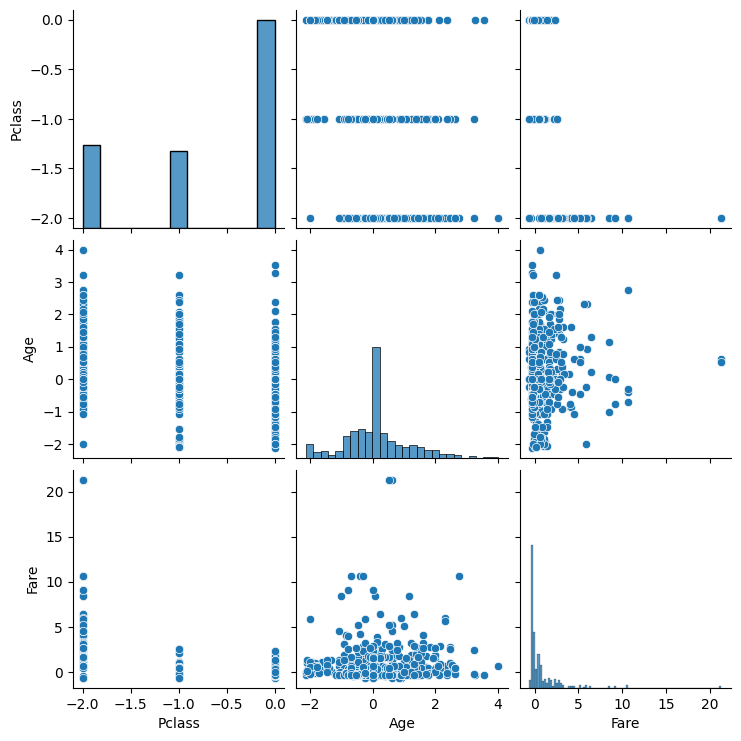

In [33]:
sns.pairplot(df_robust_scaler)

(array([ 29.,   9.,   9.,  23.,  50.,  63., 180.,  56.,  50.,  25.,  24.,
         27.,  16.,  15.,  10.,   5.,   0.,   3.,   1.,   1.]),
 array([-2.12153846, -1.81546154, -1.50938462, -1.20330769, -0.89723077,
        -0.59115385, -0.28507692,  0.021     ,  0.32707692,  0.63315385,
         0.93923077,  1.24530769,  1.55138462,  1.85746154,  2.16353846,
         2.46961538,  2.77569231,  3.08176923,  3.38784615,  3.69392308,
         4.        ]),
 <BarContainer object of 20 artists>)

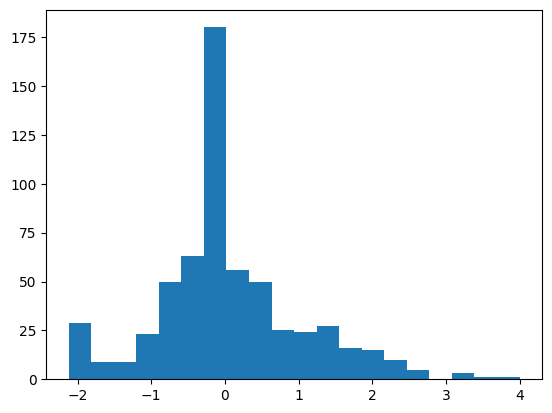

In [34]:
plt.hist(df_robust_scaler['Age'],bins=20)

(array([384., 106.,  51.,  24.,   8.,   9.,   2.,   0.,   5.,   0.,   4.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.]),
 array([-0.61902355,  0.47804111,  1.57510578,  2.67217045,  3.76923512,
         4.86629979,  5.96336445,  7.06042912,  8.15749379,  9.25455846,
        10.35162313, 11.44868779, 12.54575246, 13.64281713, 14.7398818 ,
        15.83694647, 16.93401113, 18.0310758 , 19.12814047, 20.22520514,
        21.32226981]),
 <BarContainer object of 20 artists>)

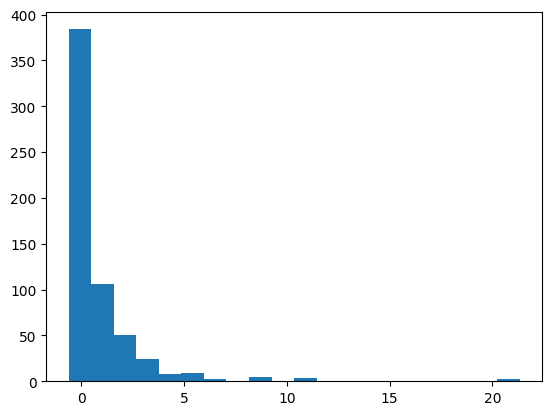

In [35]:
plt.hist(df_robust_scaler['Fare'],bins=20)

When to use which scaler?
Clean data, no outliers: Standardization or Min-Max
Data has outliers: Robust Scaler
Need values strictly 0–1: Min-Max
Neural networks / images: Min-Max
Most general ML algorithms: Standardization

## Gaussian Distribution

What does "Skewed" mean?
Skewed simply means your data is lopsided — most values are piled up on one side, with a long tail stretching out on the other side.

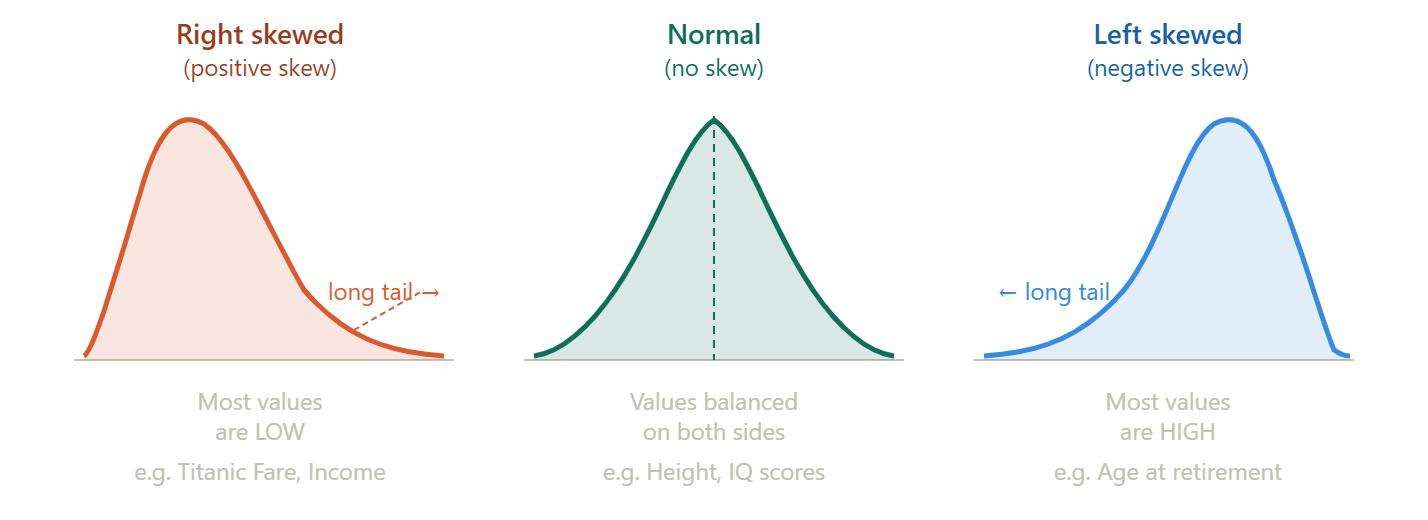

The skew is named after where the TAIL points, not where the hump is.

Right skewed  →  tail points RIGHT  →  most values are LOW
Left skewed   →  tail points LEFT   →  most values are HIGH
Normal        →  no tail, perfectly symmetric

Why it matters for ML
When data is skewed, your model sees a distorted picture. Gaussian Transformation pulls that long tail back in, making the data symmetric — and your model performs much better.




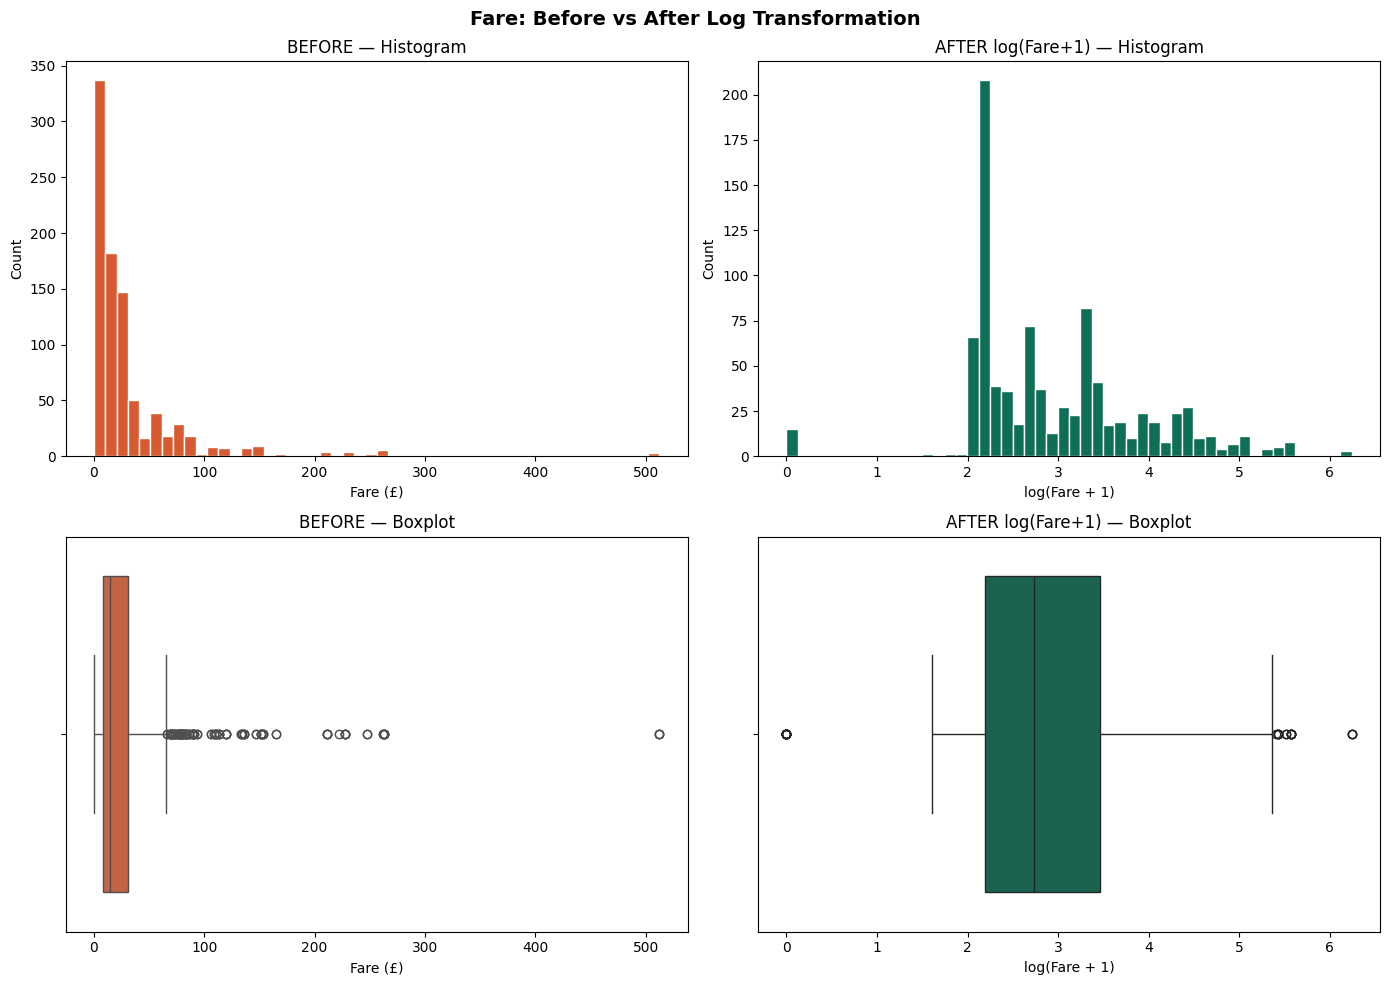

Skewness BEFORE: 4.7873
Skewness AFTER:  0.3949


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('titanic.csv', usecols=['Pclass', 'Age', 'Fare', 'Survived'])

# Apply log transformation
df['Fare_log'] = np.log(df['Fare'] + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Row 1: Histograms ---
axes[0, 0].hist(df['Fare'], bins=50, color='#D85A30', edgecolor='white')
axes[0, 0].set_title('BEFORE — Histogram')
axes[0, 0].set_xlabel('Fare (£)')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(df['Fare_log'], bins=50, color='#0F6E56', edgecolor='white')
axes[0, 1].set_title('AFTER log(Fare+1) — Histogram')
axes[0, 1].set_xlabel('log(Fare + 1)')
axes[0, 1].set_ylabel('Count')

# --- Row 2: Boxplots ---
sns.boxplot(x=df['Fare'],     ax=axes[1, 0], color='#D85A30')
axes[1, 0].set_title('BEFORE — Boxplot')
axes[1, 0].set_xlabel('Fare (£)')

sns.boxplot(x=df['Fare_log'], ax=axes[1, 1], color='#0F6E56')
axes[1, 1].set_title('AFTER log(Fare+1) — Boxplot')
axes[1, 1].set_xlabel('log(Fare + 1)')

plt.suptitle('Fare: Before vs After Log Transformation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Skewness comparison ---
print(f"Skewness BEFORE: {df['Fare'].skew():.4f}")
print(f"Skewness AFTER:  {df['Fare_log'].skew():.4f}")

log(x) is only guaranteed positive when x > 1. For values between 0 and 1, it gives you a negative result.

## Reciprocal Transformation

Reciprocal transformation is the simplest formula of all: x_new = 1 / x
That's it. You just flip the value upside down. It's called "reciprocal" because the reciprocal of any number x is simply 1/x.

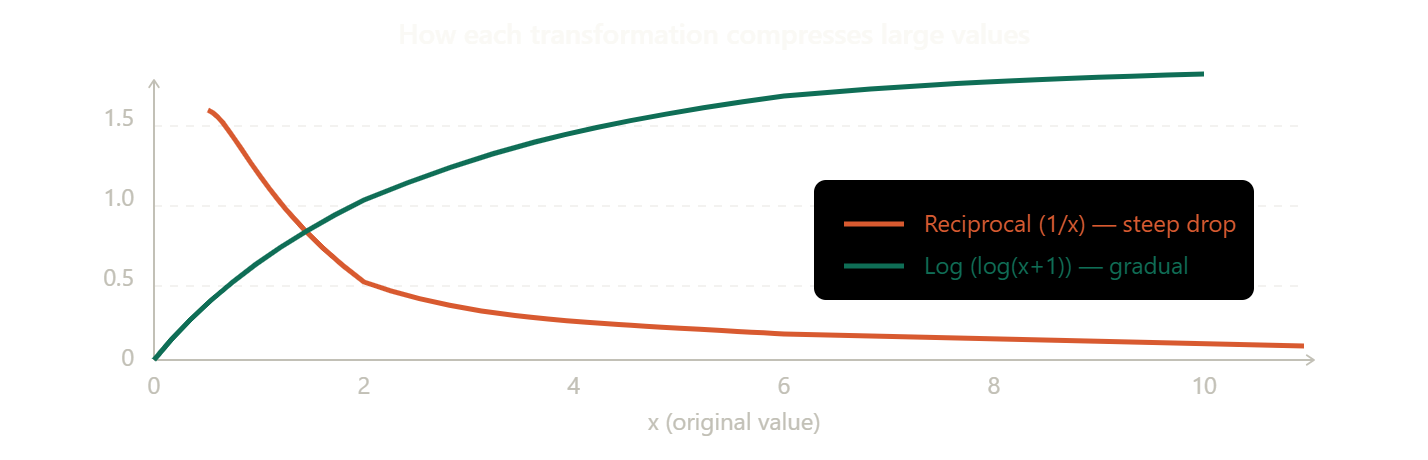


Zero Fare count: 15
Infinity count: 0


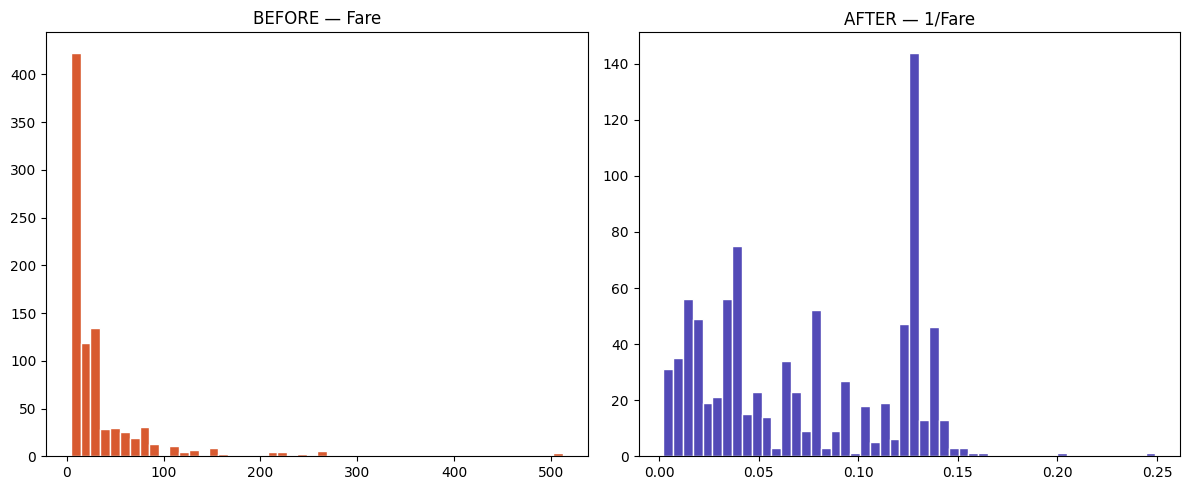

Skewness BEFORE: 4.7701
Skewness AFTER:  0.1540


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv', usecols=['Pclass', 'Age', 'Fare', 'Survived'])

# Check how many zeros exist
print(f"Zero Fare count: {(df['Fare'] == 0).sum()}")

# Fix 1 — Remove rows where Fare is 0
df = df[df['Fare'] != 0]

# Now apply reciprocal safely
df['Fare_reciprocal'] = 1 / df['Fare']

# Confirm no infinity values
print(f"Infinity count: {np.isinf(df['Fare_reciprocal']).sum()}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Fare'],            bins=50, color='#D85A30', edgecolor='white')
axes[0].set_title('BEFORE — Fare')

axes[1].hist(df['Fare_reciprocal'], bins=50, color='#534AB7', edgecolor='white')
axes[1].set_title('AFTER — 1/Fare')

plt.tight_layout()
plt.show()

print(f"Skewness BEFORE: {df['Fare'].skew():.4f}")
print(f"Skewness AFTER:  {df['Fare_reciprocal'].skew():.4f}")

In practice, log is almost always tried first. Reciprocal is a stronger tool you reach for when log isn't enough.

## Square Root Transformation

Square root transformation is the gentlest way to fix right skewness. Instead of log or reciprocal, you simply take the square root of every value: 

x_new = √x

### Bigger picture:

No transformation   →  skewness stays high

Square Root         →  gentle compression

Log                 →  stronger compression

Reciprocal          →  most aggressive compression

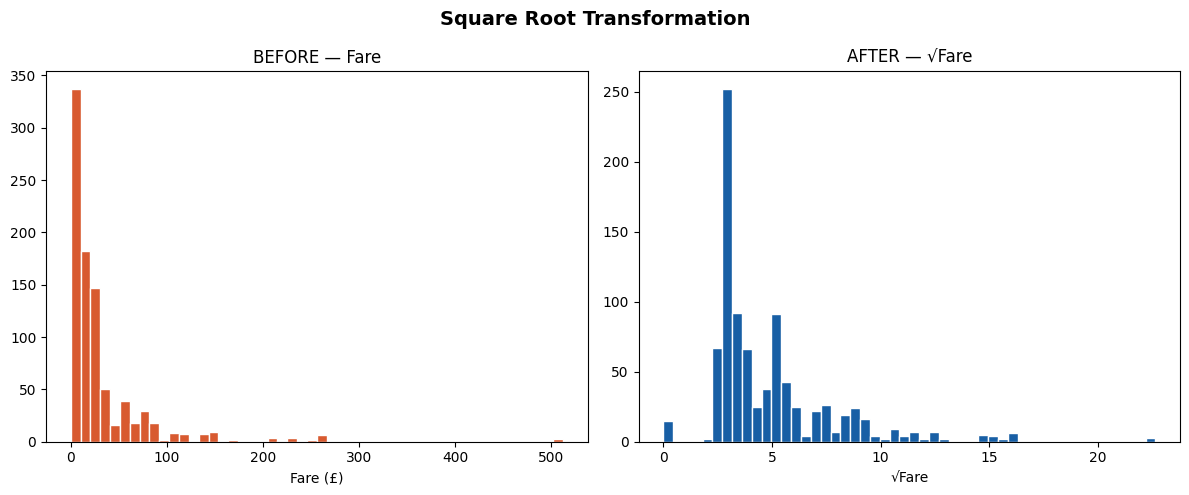

Skewness BEFORE: 4.7873
Skewness AFTER:  2.0850


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv', usecols=['Pclass', 'Age', 'Fare', 'Survived'])

# Apply square root transformation
df['Fare_sqrt'] = np.sqrt(df['Fare'])

# Plot before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Fare'],      bins=50, color='#D85A30', edgecolor='white')
axes[0].set_title('BEFORE — Fare')
axes[0].set_xlabel('Fare (£)')

axes[1].hist(df['Fare_sqrt'], bins=50, color='#185FA5', edgecolor='white')
axes[1].set_title('AFTER — √Fare')
axes[1].set_xlabel('√Fare')

plt.suptitle('Square Root Transformation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness BEFORE: {df['Fare'].skew():.4f}")
print(f"Skewness AFTER:  {df['Fare_sqrt'].skew():.4f}")

## Exponential Transformation

Exponential is the opposite — it fixes left skewed data by stretching out the large values.

x²     →  square (squaring)

x³     →  cube

eˣ     →  natural exponential (most powerful)

You pick based on how severe the left skew is — just like how we picked between sqrt, log and reciprocal for right skew.

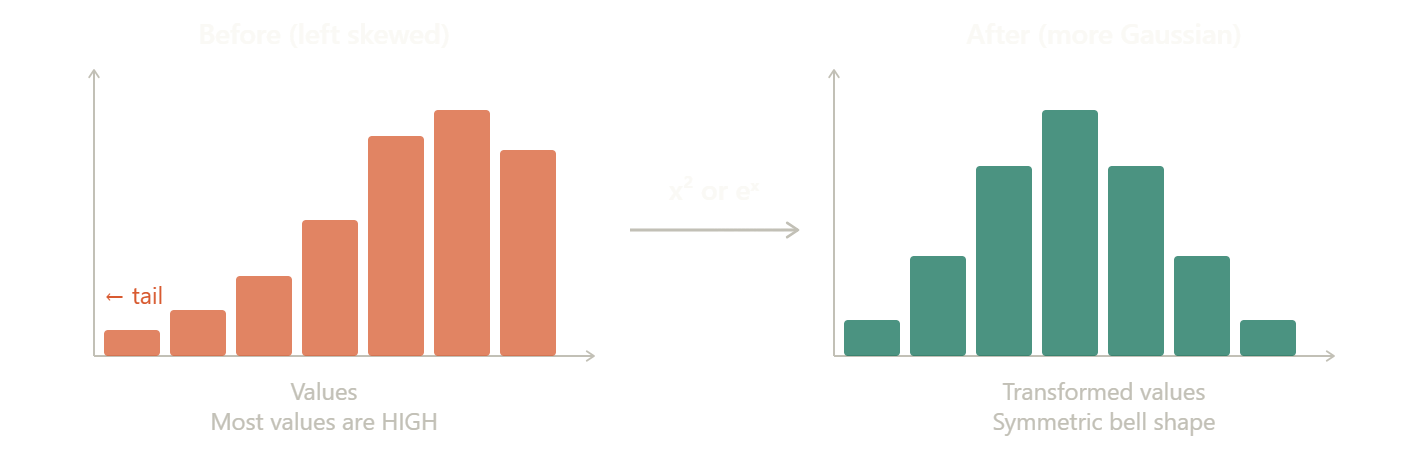

Age skewness:    0.3891
Pclass skewness: -0.6305


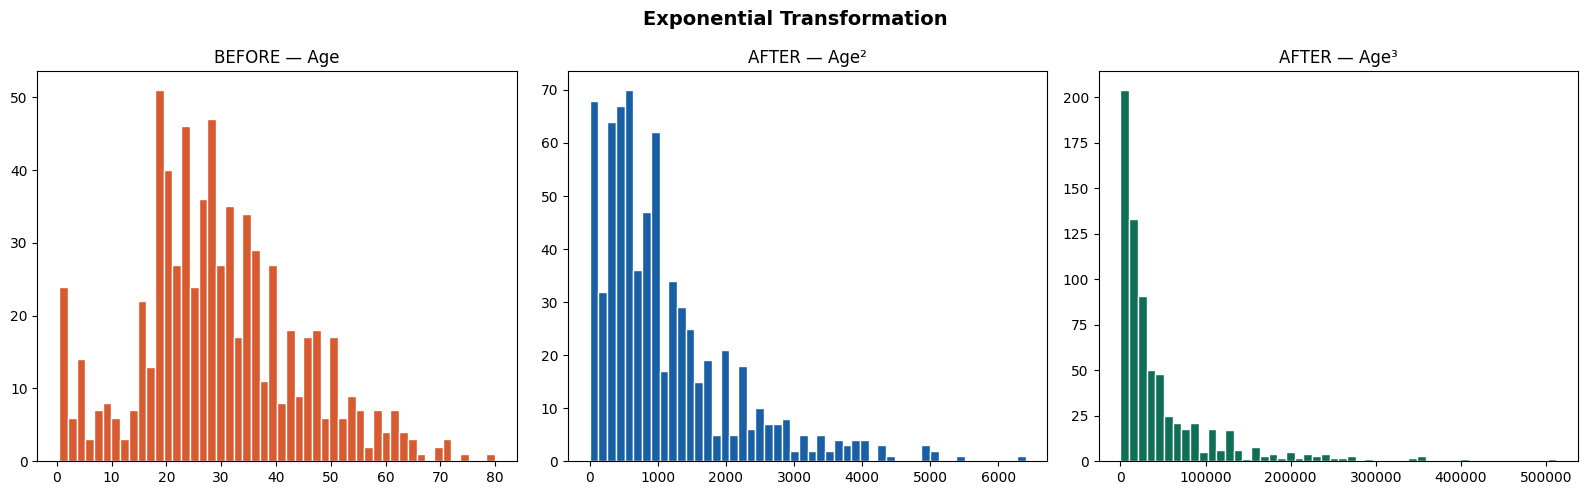

Skewness BEFORE:  0.3891
Skewness Age²:    1.6757
Skewness Age³:    2.7621


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv', usecols=['Pclass', 'Age', 'Fare', 'Survived'])

# Check skewness first
print(f"Age skewness:    {df['Age'].skew():.4f}")
print(f"Pclass skewness: {df['Pclass'].skew():.4f}")

# Apply exponential transformations
df['Age_sq']  = df['Age'] ** 2          # squaring
df['Age_cb']  = df['Age'] ** 3          # cubing
df['Age_exp'] = np.exp(df['Age'])       # most powerful — careful!

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['Age'],    bins=50, color='#D85A30', edgecolor='white')
axes[0].set_title('BEFORE — Age')

axes[1].hist(df['Age_sq'], bins=50, color='#185FA5', edgecolor='white')
axes[1].set_title('AFTER — Age²')

axes[2].hist(df['Age_cb'], bins=50, color='#0F6E56', edgecolor='white')
axes[2].set_title('AFTER — Age³')

plt.suptitle('Exponential Transformation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness BEFORE:  {df['Age'].skew():.4f}")
print(f"Skewness Age²:    {df['Age_sq'].skew():.4f}")
print(f"Skewness Age³:    {df['Age_cb'].skew():.4f}")

Age in the Titanic dataset is actually right skewed — not left skewed! There are more young passengers than old ones. So applying an exponential transformation (which is meant for left skewed data) pushed it further right.

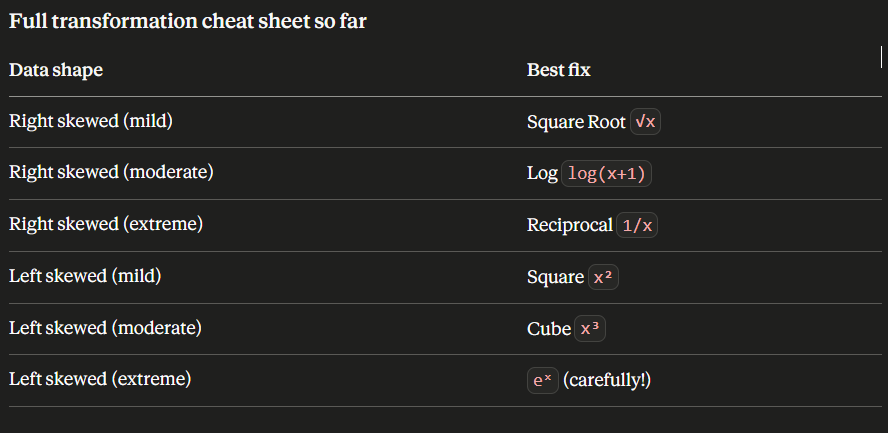

## Box-Cox Transformation

All the previous transformations required you to decide:

"Is this right skewed? How severe? Should I use log or reciprocal or sqrt?"

Box-Cox removes that guesswork entirely. It automatically finds the best transformation by testing a parameter called lambda (λ) and picking the value that makes your data most Gaussian.

How it works internally?

Box-Cox tries a range of λ values and picks the one that best normalizes your data:

λ = -1    →  Reciprocal (1/x)

λ =  0    →  Log (log(x))

λ =  0.5  →  Square Root (√x)

λ =  1    →  No transformation (x itself)

λ =  2    →  Square (x²)

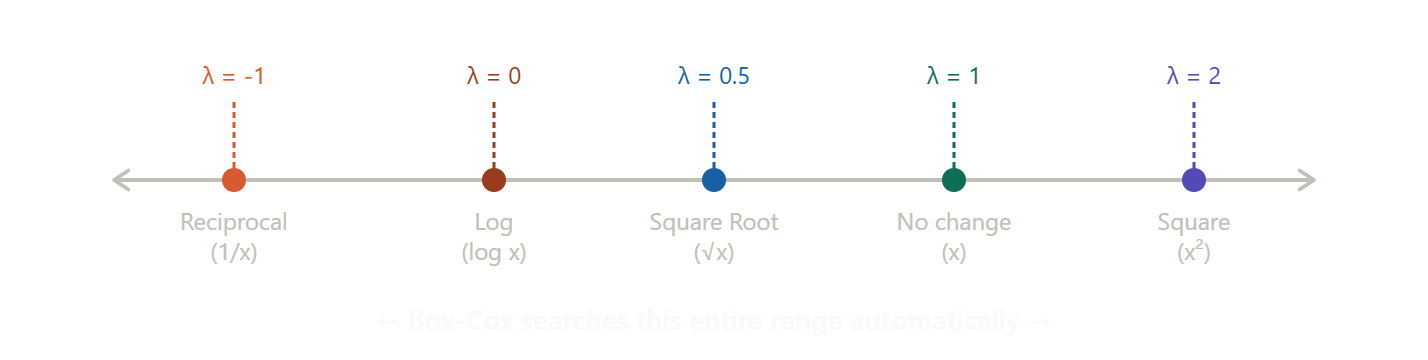

Formula:

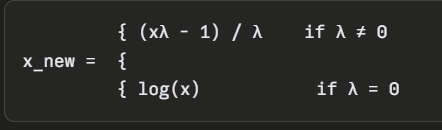

Zero Fare count: 7
Best Lambda found: -0.4691


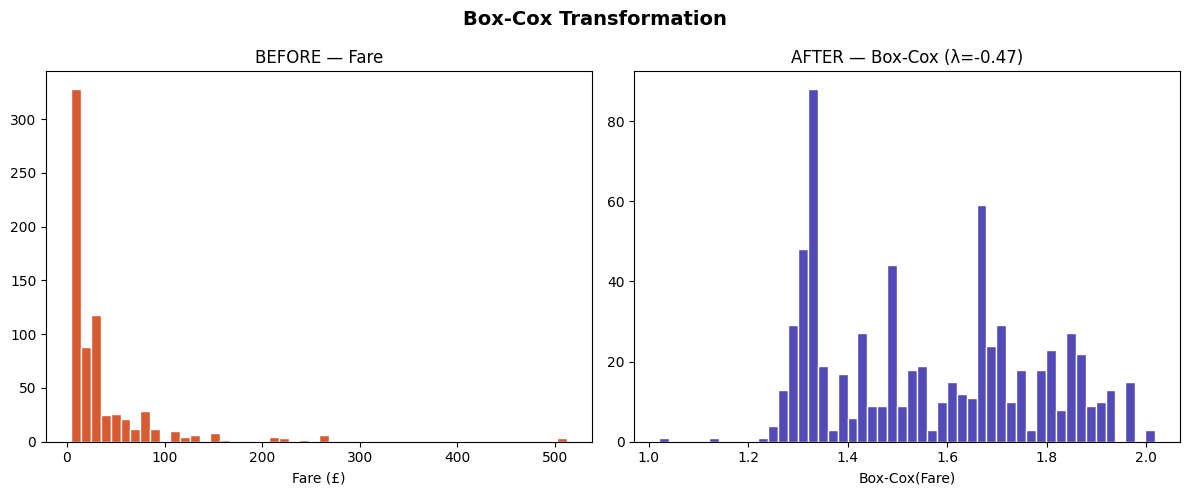

Skewness BEFORE: 4.6439
Skewness AFTER:  0.1846


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('titanic.csv', usecols=['Pclass', 'Age', 'Fare', 'Survived'])

# Drop nulls
df.dropna(inplace=True)

# Check zeros
print(f"Zero Fare count: {(df['Fare'] == 0).sum()}")

# Fix — drop rows where Fare is zero
df = df[df['Fare'] > 0]

# Now Box-Cox is safe
df['Fare_boxcox'], lambda_val = stats.boxcox(df['Fare'])

print(f"Best Lambda found: {lambda_val:.4f}")

# Plot before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Fare'],        bins=50, color='#D85A30', edgecolor='white')
axes[0].set_title('BEFORE — Fare')
axes[0].set_xlabel('Fare (£)')

axes[1].hist(df['Fare_boxcox'], bins=50, color='#534AB7', edgecolor='white')
axes[1].set_title(f'AFTER — Box-Cox (λ={lambda_val:.2f})')
axes[1].set_xlabel('Box-Cox(Fare)')

plt.suptitle('Box-Cox Transformation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness BEFORE: {df['Fare'].skew():.4f}")
print(f"Skewness AFTER:  {df['Fare_boxcox'].skew():.4f}")